In [1]:
"""
NexaCore Enterprise Intelligence Platform
Stage 7 — EDA & Statistical Modeling
Notebook 04: Inventory Stockout Risk — EDA & Analysis

Business Question:
    Which inventory items are at greatest risk of stocking out,
    and can we predict stockout risk with statistical confidence
    given a 400-record point-in-time dataset?

Audience: Data Analyst + Data Scientist
"""

'\nNexaCore Enterprise Intelligence Platform\nStage 7 — EDA & Statistical Modeling\nNotebook 04: Inventory Stockout Risk — EDA & Analysis\n\nBusiness Question:\n    Which inventory items are at greatest risk of stocking out,\n    and can we predict stockout risk with statistical confidence\n    given a 400-record point-in-time dataset?\n\nAudience: Data Analyst + Data Scientist\n'

# Inventory Stockout Risk — EDA & Statistical Analysis

**ML Problem:** Binary classification — predict which inventory items
will run out of stock before replenishment.

**Target:** `stockout_risk_flag_target` (1=at risk, 0=adequate)
**Grain:** One row per inventory item (product × warehouse snapshot)

---
### Critical Limitation (must be referenced in conclusions)
> **n=400 point-in-time records.** This is a single snapshot on 2026-06-30.
> There is no time dimension — this analysis is entirely cross-sectional.
> A daily time-series would be required for proper dynamic stockout prediction.
> Stage 8 models must prioritise interpretability over complexity (n=400 insufficient for deep learning).

## 0. Setup

In [2]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as sp_stats
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

from data_science.config import PALETTE, CATEGORICAL_PALETTE, CONTROL_TOTALS, DATASET_LIMITATIONS, ALPHA
from data_science.db import load_inventory_features
from data_science.stats import mannwhitney, chi_square, results_table
from data_science.feature_profile import profile_dataframe, flag_data_quality_issues, summarize_target
from data_science.plotting import save_figure, plot_feature_importance

pd.set_option("display.float_format", "{:,.4f}".format)
print("✓ Setup complete")

✓ Setup complete


## 1. Business Question

1. What fraction of inventory items are currently at stockout risk?
2. Which warehouses and product categories have the highest risk concentration?
3. Are the risk predictors statistically different between at-risk and safe items?
4. Can a simple rule-based classifier (decision tree depth=3) match a logistic model?
5. Is n=400 sufficient for ML training — or should Stage 8 use rule-based approaches?
6. What decision boundary separates stockout risk from safety stock adequacy?

## 2. Data Loading & Understanding

In [3]:
print(f"\n[LIMITATION] {DATASET_LIMITATIONS['inventory_grain']}\n")

df = load_inventory_features()
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"\nUnique products:   {df['product_id'].nunique()}")
print(f"Unique warehouses: {df['warehouse_id'].nunique()}")
print(f"Total rows:        {len(df):,}  (canonical: {CONTROL_TOTALS['stockout_risk_rows']:,})")
display(df.head(5))


[LIMITATION] fact_inventory_snapshot contains 400 point-in-time records on a single snapshot date (2026-06-30). This is NOT a daily time-series. Stockout risk analysis is cross-sectional, not longitudinal.

Shape: (400, 18)
Columns: ['inventory_id', 'product_id', 'warehouse_id', 'product_name', 'category_name', 'warehouse_name', 'warehouse_location', 'quantity_on_hand', 'quantity_allocated', 'quantity_available', 'reorder_point', 'reorder_quantity', 'days_of_supply', 'unit_cost', 'unit_price', 'inventory_value_usd', 'stockout_risk_flag_target', 'is_below_reorder_point']

Unique products:   100
Unique warehouses: 4
Total rows:        400  (canonical: 400)


,inventory_id,product_id,warehouse_id,product_name,category_name,warehouse_name,warehouse_location,quantity_on_hand,quantity_allocated,quantity_available,reorder_point,reorder_quantity,days_of_supply,unit_cost,unit_price,inventory_value_usd,stockout_risk_flag_target,is_below_reorder_point
0,1,bdd640fb-0667-1ad1-1c80-317fa3b1799d,f16287e4-e9c3-49e0-3602-f8ac10f1bc81,Electrical & Automatio Component Grade-A,Electrical & Automation,Chicago Logistics Hub,North America,704,14,690,100,200,180.0000,389.2400,631.7500,"274,024.9600",0,0
1,2,bd9c66b3-ad3c-2d6d-1a3d-1fa7bc8960a9,f16287e4-e9c3-49e0-3602-f8ac10f1bc81,Industrial Fastener Component Grade-A,Industrial Fasteners,Chicago Logistics Hub,North America,75,35,40,500,1000,0.0000,430.7100,793.7000,"32,303.2500",1,1
2,3,3b8faa18-37f8-a88b-17fc-695a07a0ca6e,f16287e4-e9c3-49e0-3602-f8ac10f1bc81,Pipes & Fitting Component Grade-C,Pipes & Fittings,Chicago Logistics Hub,North America,300,28,272,50,100,150.0000,56.1500,116.7500,"16,845.0000",0,0
3,4,b38a088c-a65e-d389-b74d-0fb132e70629,f16287e4-e9c3-49e0-3602-f8ac10f1bc81,Pumps & Valve Component Grade-B,Pumps & Valves,Chicago Logistics Hub,North America,192,94,98,100,200,0.0000,382.9600,734.5800,"73,528.3200",1,1
4,5,de8a774b-cf36-d58b-4737-819096da1dac,f16287e4-e9c3-49e0-3602-f8ac10f1bc81,Bearings & Power Transmissio Component Grade-B,Bearings & Power Transmission,Chicago Logistics Hub,North America,154,86,68,500,1000,0.0000,72.7800,118.8400,"11,208.1200",1,1


## 3. Data Quality Assessment

In [4]:
FEATURE_COLS = ["quantity_on_hand","quantity_allocated","quantity_available","reorder_point"]

profile = profile_dataframe(df[FEATURE_COLS + ["stockout_risk_flag_target"]], target_col="stockout_risk_flag_target")
print("=== Feature Profile ===")
display(profile[["column","n_missing","pct_missing","mean","median","std","skewness","outliers_iqr_pct","normality","target_corr_r","target_corr_sig"]])

issues = flag_data_quality_issues(profile)
print(f"\nDQ Issues: {len(issues)}")
if len(issues):
    display(issues)
else:
    print("  ✅ No critical DQ issues.")

# Derived feature: buffer ratio
df["buffer_ratio"] = df["quantity_available"] / df["reorder_point"].replace(0, np.nan)
df["safety_margin"] = df["quantity_available"] - df["reorder_point"]

=== Feature Profile ===


,column,n_missing,pct_missing,mean,median,std,skewness,outliers_iqr_pct,normality,target_corr_r,target_corr_sig
0,quantity_on_hand,0,0.0000,525.4350,509.5000,278.9131,0.0760,0.0000,not normal,-0.5490,yes
1,quantity_allocated,0,0.0000,50.1625,51.5000,29.5067,-0.0474,0.0000,not normal,0.0641,no
2,quantity_available,0,0.0000,475.2725,466.0000,280.3308,0.0782,0.0000,not normal,-0.5530,yes
3,reorder_point,0,0.0000,222.5000,100.0000,184.4011,0.7095,0.0000,not normal,0.4658,yes
4,stockout_risk_flag_target,0,0.0000,0.2125,0.0000,0.4096,1.4109,21.2500,not normal,1.0000,yes



DQ Issues: 1


,column,dtype,issues
0,stockout_risk_flag_target,int64,OUTLIERS: 21.25% IQR outliers


## 4. Target Distribution (Univariate)

=== TARGET DISTRIBUTION ===
  target                   : stockout_risk_flag_target
  n                        : 400
  n_missing                : 0
  n_unique                 : 2
  dtype                    : int64
  type                     : binary
  class_0_pct              : 78.75
  class_1_pct              : 21.25
  imbalance_ratio          : 3.71
  imbalance_verdict        : mild (2:1-5:1)


  [saved] C:\Users\NAGESH REDDY\Desktop\Data Analytics\enterprise-intelligence-platform\docs\data_science\figures\04_stockout_target_distribution.png


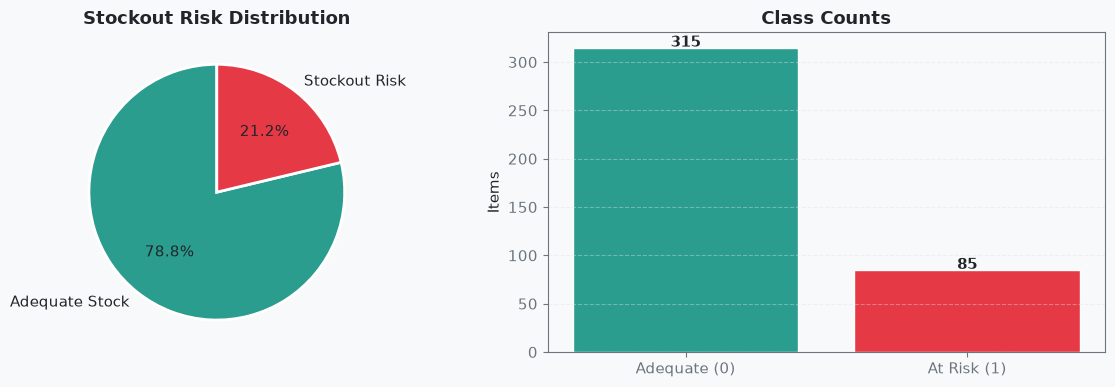


  Stockout risk rate: 21.25%  (85 items)
  Imbalance: mild (2:1-5:1)


In [5]:
target_summary = summarize_target(df["stockout_risk_flag_target"], "stockout_risk_flag_target")
risk_rate = target_summary["class_1_pct"]

print("=== TARGET DISTRIBUTION ===")
for k, v in target_summary.items():
    print(f"  {k:<25}: {v}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].pie(
    [target_summary["class_0_pct"], risk_rate],
    labels=["Adequate Stock", "Stockout Risk"],
    autopct="%1.1f%%",
    colors=[PALETTE["success"], PALETTE["danger"]],
    startangle=90, wedgeprops={"edgecolor": "white", "linewidth": 2},
)
axes[0].set_title("Stockout Risk Distribution")

counts = df["stockout_risk_flag_target"].value_counts().sort_index()
axes[1].bar(["Adequate (0)", "At Risk (1)"], counts.values,
            color=[PALETTE["success"], PALETTE["danger"]], edgecolor="white")
for i, v in enumerate(counts.values):
    axes[1].text(i, v + 1, str(v), ha="center", fontweight="bold")
axes[1].set_ylabel("Items")
axes[1].set_title("Class Counts")
axes[1].grid(True, alpha=0.4, axis="y")

plt.tight_layout()
save_figure(fig, "04_stockout_target_distribution")
plt.show()

print(f"\n  Stockout risk rate: {risk_rate:.2f}%  ({int(risk_rate/100*len(df))} items)")
print(f"  Imbalance: {target_summary['imbalance_verdict']}")

## 5. Bivariate Analysis — Risk by Warehouse & Category

  [saved] C:\Users\NAGESH REDDY\Desktop\Data Analytics\enterprise-intelligence-platform\docs\data_science\figures\04_stockout_risk_by_segment.png


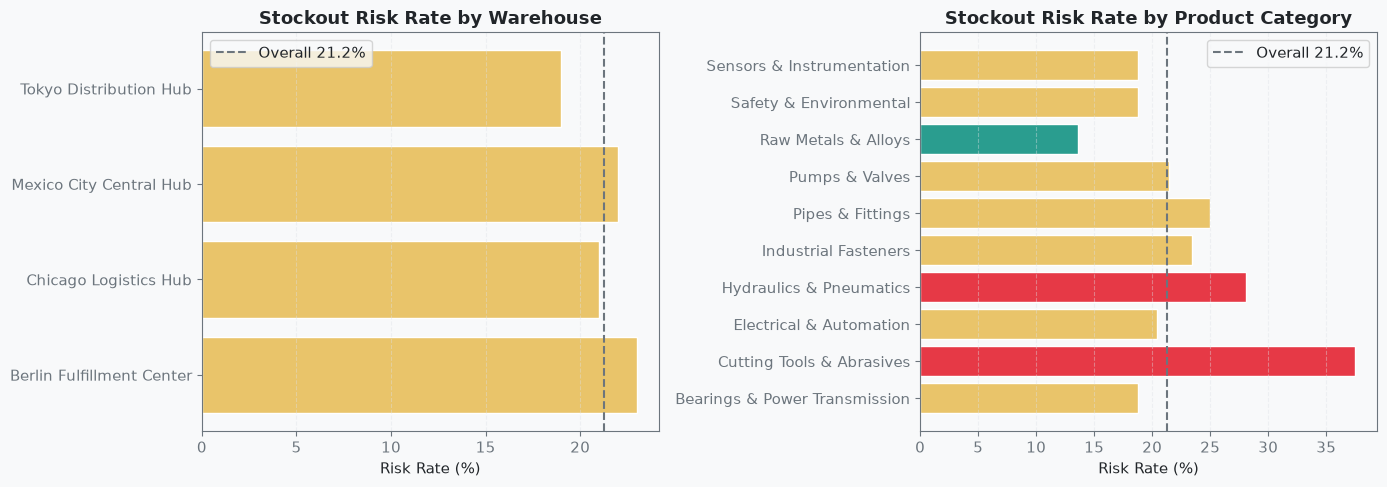


📊 Risk by Warehouse:


,warehouse_name,risk_rate,total,at_risk,risk_rate_pct
0,Berlin Fulfillment Center,0.2300,100,23,23.0000
2,Mexico City Central Hub,0.2200,100,22,22.0000
1,Chicago Logistics Hub,0.2100,100,21,21.0000
3,Tokyo Distribution Hub,0.1900,100,19,19.0000



📊 Risk by Category:


,category_name,risk_rate,total,at_risk,risk_rate_pct
1,Cutting Tools & Abrasives,0.3750,16,6,37.5000
3,Hydraulics & Pneumatics,0.2812,32,9,28.1200
5,Pipes & Fittings,0.2500,28,7,25.0000
4,Industrial Fasteners,0.2344,64,15,23.4400
6,Pumps & Valves,0.2143,28,6,21.4300
2,Electrical & Automation,0.2045,44,9,20.4500
0,Bearings & Power Transmission,0.1875,48,9,18.7500
8,Safety & Environmental,0.1875,64,12,18.7500
9,Sensors & Instrumentation,0.1875,32,6,18.7500
7,Raw Metals & Alloys,0.1364,44,6,13.6400


In [6]:
# Risk by warehouse
risk_by_wh = (
    df.groupby("warehouse_name")["stockout_risk_flag_target"]
    .agg(["mean","count","sum"])
    .reset_index()
    .rename(columns={"mean":"risk_rate","count":"total","sum":"at_risk"})
)
risk_by_wh["risk_rate_pct"] = (risk_by_wh["risk_rate"] * 100).round(2)

# Risk by category
risk_by_cat = (
    df.groupby("category_name")["stockout_risk_flag_target"]
    .agg(["mean","count","sum"])
    .reset_index()
    .rename(columns={"mean":"risk_rate","count":"total","sum":"at_risk"})
)
risk_by_cat["risk_rate_pct"] = (risk_by_cat["risk_rate"] * 100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_wh  = [PALETTE["danger"] if r > 25 else PALETTE["warning"] if r > 15 else PALETTE["success"]
               for r in risk_by_wh["risk_rate_pct"]]
colors_cat = [PALETTE["danger"] if r > 25 else PALETTE["warning"] if r > 15 else PALETTE["success"]
               for r in risk_by_cat["risk_rate_pct"]]

axes[0].barh(risk_by_wh["warehouse_name"], risk_by_wh["risk_rate_pct"], color=colors_wh, edgecolor="white")
axes[0].axvline(risk_rate, color=PALETTE["neutral"], linestyle="--", linewidth=1.5, label=f"Overall {risk_rate:.1f}%")
axes[0].set_title("Stockout Risk Rate by Warehouse")
axes[0].set_xlabel("Risk Rate (%)")
axes[0].legend()
axes[0].grid(True, alpha=0.4, axis="x")

axes[1].barh(risk_by_cat["category_name"], risk_by_cat["risk_rate_pct"], color=colors_cat, edgecolor="white")
axes[1].axvline(risk_rate, color=PALETTE["neutral"], linestyle="--", linewidth=1.5, label=f"Overall {risk_rate:.1f}%")
axes[1].set_title("Stockout Risk Rate by Product Category")
axes[1].set_xlabel("Risk Rate (%)")
axes[1].legend()
axes[1].grid(True, alpha=0.4, axis="x")

plt.tight_layout()
save_figure(fig, "04_stockout_risk_by_segment")
plt.show()

print("\n📊 Risk by Warehouse:")
display(risk_by_wh.sort_values("risk_rate_pct", ascending=False))
print("\n📊 Risk by Category:")
display(risk_by_cat.sort_values("risk_rate_pct", ascending=False))

## 6. Feature Distributions by Risk Group

  [saved] C:\Users\NAGESH REDDY\Desktop\Data Analytics\enterprise-intelligence-platform\docs\data_science\figures\04_feature_distributions.png


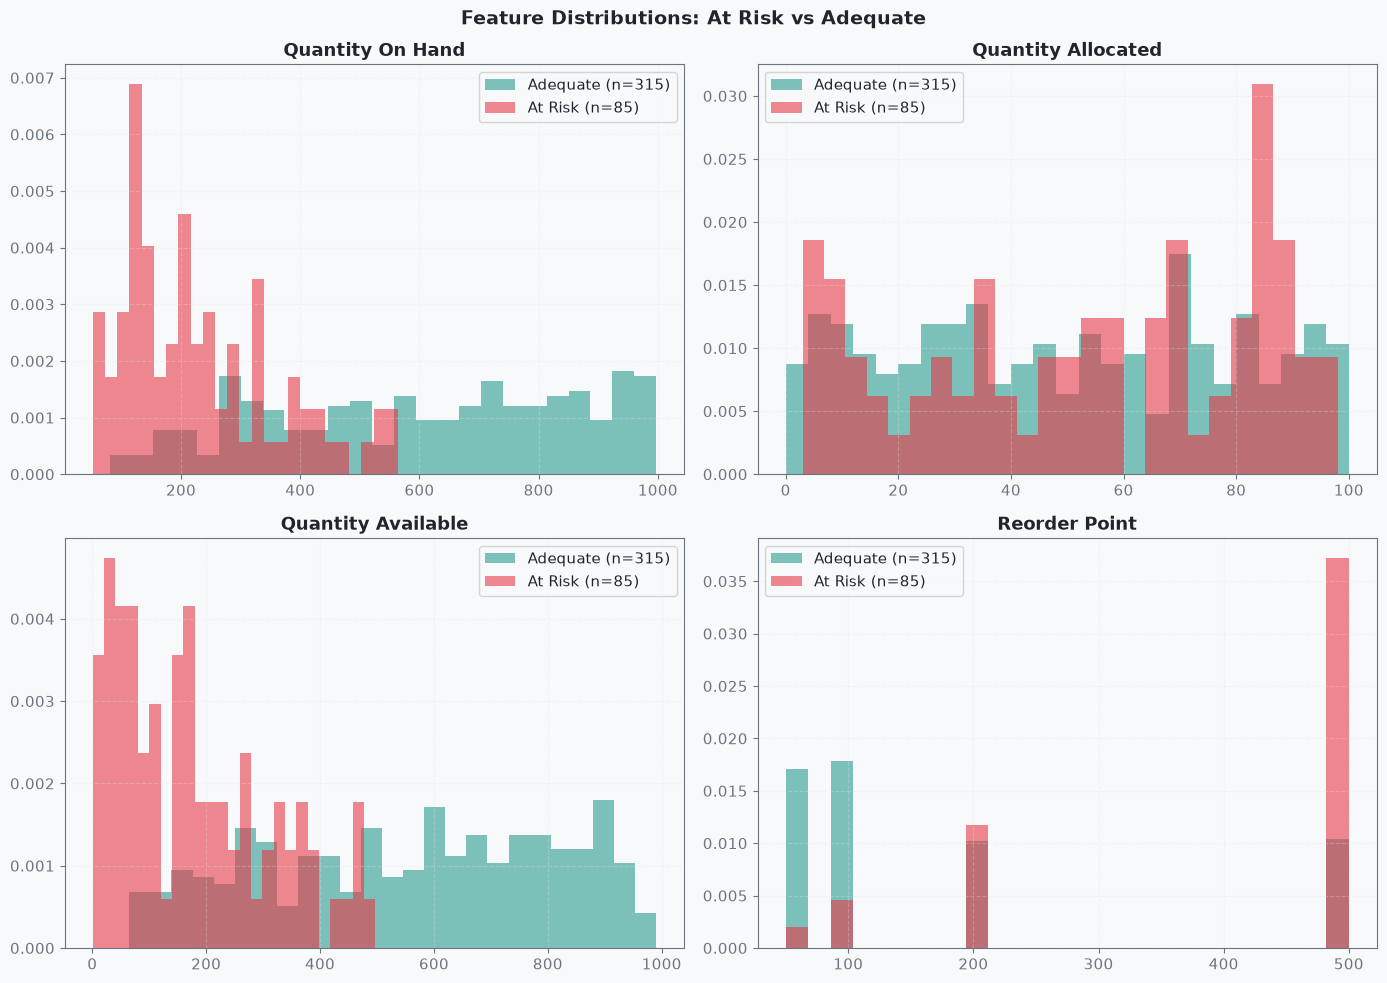

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for i, col in enumerate(FEATURE_COLS):
    at_risk = df.loc[df["stockout_risk_flag_target"]==1, col].dropna()
    adequate = df.loc[df["stockout_risk_flag_target"]==0, col].dropna()
    axes[i].hist(adequate, bins=25, alpha=0.6, color=PALETTE["success"], density=True, label=f"Adequate (n={len(adequate)})")
    axes[i].hist(at_risk,  bins=25, alpha=0.6, color=PALETTE["danger"],  density=True, label=f"At Risk (n={len(at_risk)})")
    axes[i].set_title(col.replace("_"," ").title())
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.suptitle("Feature Distributions: At Risk vs Adequate", fontsize=14, fontweight="bold")
plt.tight_layout()
save_figure(fig, "04_feature_distributions")
plt.show()

## 7. Hypothesis Tests

In [8]:
print("=== HYPOTHESIS TESTS: At Risk vs Adequate ===\n")
test_results = []
all_feature_cols = FEATURE_COLS + ["buffer_ratio","safety_margin"]

for col in all_feature_cols:
    at_risk  = df.loc[df["stockout_risk_flag_target"]==1, col].dropna()
    adequate = df.loc[df["stockout_risk_flag_target"]==0, col].dropna()
    r = mannwhitney(at_risk, adequate, label_a="At Risk", label_b="Adequate")
    r["feature"] = col
    test_results.append(r)
    status = "✅" if r["significant"] else "  "
    print(f"  {status}  {col:<25}  medians: {r['median_a']:>8.2f} vs {r['median_b']:>8.2f}  p={r['p_value']:<10}  {r['significance']}")

print("\n\n=== Chi-Square: Category vs Stockout Risk ===")
ct = pd.crosstab(df["category_name"], df["stockout_risk_flag_target"])
chi_r = chi_square(ct)
for k, v in chi_r.items():
    print(f"  {k}: {v}")

print("\n=== Chi-Square: Warehouse vs Stockout Risk ===")
ct_wh = pd.crosstab(df["warehouse_name"], df["stockout_risk_flag_target"])
chi_wh = chi_square(ct_wh)
for k, v in chi_wh.items():
    print(f"  {k}: {v}")

=== HYPOTHESIS TESTS: At Risk vs Adequate ===

  ✅  quantity_on_hand           medians:   208.00 vs   624.00  p=0.0         *** (p<0.001)
      quantity_allocated         medians:    58.00 vs    50.00  p=0.204159    ns  (not significant)
  ✅  quantity_available         medians:   155.00 vs   585.00  p=0.0         *** (p<0.001)
  ✅  reorder_point              medians:   500.00 vs   100.00  p=0.0         *** (p<0.001)
  ✅  buffer_ratio               medians:     0.47 vs     3.96  p=0.0         *** (p<0.001)
  ✅  safety_margin              medians:  -181.00 vs   358.00  p=0.0         *** (p<0.001)


=== Chi-Square: Category vs Stockout Risk ===
  test: Chi-square test of independence
  chi2_statistic: 5.926
  degrees_of_freedom: 9
  p_value: 0.7473
  significant: False
  significance: ns  (not significant)
  cramers_v: 0.1217
  effect_size: negligible

=== Chi-Square: Warehouse vs Stockout Risk ===
  test: Chi-square test of independence
  chi2_statistic: 0.5229
  degrees_of_freedom: 3
  

## 8. Business Rule Extraction (Decision Tree depth=3)

In [9]:
X_tree = df[FEATURE_COLS].fillna(df[FEATURE_COLS].median())
y_tree = df["stockout_risk_flag_target"]

dt = DecisionTreeClassifier(max_depth=3, min_samples_leaf=5, random_state=42)
dt.fit(X_tree, y_tree)

print("=== DECISION TREE — Extracted Business Rules (depth=3) ===\n")
print(export_text(dt, feature_names=FEATURE_COLS))

# Feature importance from tree
dt_importance = pd.DataFrame({
    "feature": FEATURE_COLS,
    "importance": dt.feature_importances_,
}).sort_values("importance", ascending=False)
print("\nTree feature importance:")
display(dt_importance)

# Evaluate tree
from sklearn.metrics import accuracy_score, precision_score, recall_score
y_pred_tree = dt.predict(X_tree)
print(f"\nTree in-sample performance:")
print(f"  Accuracy:  {accuracy_score(y_tree, y_pred_tree):.4f}")
print(f"  Precision: {precision_score(y_tree, y_pred_tree, zero_division=0):.4f}")
print(f"  Recall:    {recall_score(y_tree, y_pred_tree, zero_division=0):.4f}")

=== DECISION TREE — Extracted Business Rules (depth=3) ===

|--- quantity_on_hand <= 260.00
|   |--- reorder_point <= 150.00
|   |   |--- quantity_available <= 64.00
|   |   |   |--- class: 1
|   |   |--- quantity_available >  64.00
|   |   |   |--- class: 0
|   |--- reorder_point >  150.00
|   |   |--- quantity_available <= 195.00
|   |   |   |--- class: 1
|   |   |--- quantity_available >  195.00
|   |   |   |--- class: 1
|--- quantity_on_hand >  260.00
|   |--- reorder_point <= 350.00
|   |   |--- class: 0
|   |--- reorder_point >  350.00
|   |   |--- quantity_available <= 501.00
|   |   |   |--- class: 1
|   |   |--- quantity_available >  501.00
|   |   |   |--- class: 0


Tree feature importance:


,feature,importance
2,quantity_available,0.3919
0,quantity_on_hand,0.3280
3,reorder_point,0.2801
1,quantity_allocated,0.0000



Tree in-sample performance:
  Accuracy:  0.9925
  Precision: 0.9881
  Recall:    0.9765


## 8b. Logistic Regression (CV)

In [10]:
X_lr = df[FEATURE_COLS].fillna(df[FEATURE_COLS].median())
y_lr = df["stockout_risk_flag_target"]

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(class_weight="balanced", max_iter=500, random_state=42)),
])

cv_results = cross_validate(
    pipe, X_lr, y_lr,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring=["roc_auc","f1","precision","recall"],
)

print("=== LOGISTIC REGRESSION (5-fold stratified CV) ===")
for metric in ["roc_auc","f1","precision","recall"]:
    vals = cv_results[f"test_{metric}"]
    print(f"  {metric:<12}: {vals.mean():.4f} ± {vals.std():.4f}")

=== LOGISTIC REGRESSION (5-fold stratified CV) ===
  roc_auc     : 0.9993 ± 0.0011
  f1          : 0.9507 ± 0.0314
  precision   : 0.9078 ± 0.0578
  recall      : 1.0000 ± 0.0000


## 9. Sample Size & Power Analysis

In [11]:
from scipy.stats import norm as sp_norm

print("=== POWER ANALYSIS — n=400 dataset ===\n")

n_total = len(df)
n_risk  = int(df["stockout_risk_flag_target"].sum())
n_safe  = n_total - n_risk
print(f"  Total items:     {n_total}")
print(f"  At risk:         {n_risk} ({n_risk/n_total*100:.1f}%)")
print(f"  Adequate:        {n_safe} ({n_safe/n_total*100:.1f}%)")

# Power to detect d=0.3 effect at alpha=0.05
for d in [0.2, 0.3, 0.5, 0.8]:
    n_needed = ((sp_norm.ppf(0.975) + sp_norm.ppf(0.80)) / d) ** 2 * 2
    print(f"  Effect d={d}: need n={n_needed:.0f} per group  ({'SUFFICIENT' if min(n_risk,n_safe) >= n_needed else 'INSUFFICIENT'})")

print(f"""
ASSESSMENT:
  Current dataset (n=400, {n_risk} at-risk, {n_safe} adequate) is
  {'SUFFICIENT' if n_risk >= 30 else 'MARGINAL'} for simple classifiers and business rule derivation.
  NOT sufficient for deep learning or high-cardinality feature spaces.
  
  RECOMMENDATION for Stage 8:
  • Use Logistic Regression or Decision Tree (interpretable, n-appropriate)
  • Avoid XGBoost with large feature sets (risk of overfitting at n=400)
  • Use LOOCV or 5-fold stratified CV for reliable evaluation
  • Report confidence intervals on all metrics
""")

=== POWER ANALYSIS — n=400 dataset ===

  Total items:     400
  At risk:         85 (21.2%)
  Adequate:        315 (78.8%)
  Effect d=0.2: need n=392 per group  (INSUFFICIENT)
  Effect d=0.3: need n=174 per group  (INSUFFICIENT)
  Effect d=0.5: need n=63 per group  (SUFFICIENT)
  Effect d=0.8: need n=25 per group  (SUFFICIENT)

ASSESSMENT:
  Current dataset (n=400, 85 at-risk, 315 adequate) is
  SUFFICIENT for simple classifiers and business rule derivation.
  NOT sufficient for deep learning or high-cardinality feature spaces.

  RECOMMENDATION for Stage 8:
  • Use Logistic Regression or Decision Tree (interpretable, n-appropriate)
  • Avoid XGBoost with large feature sets (risk of overfitting at n=400)
  • Use LOOCV or 5-fold stratified CV for reliable evaluation
  • Report confidence intervals on all metrics



## 10-13. Leakage Risks, Features, Stage 8 Recommendation & Conclusions

In [12]:
print("=" * 65)
print("  STATISTICAL CONCLUSIONS — Inventory Stockout Risk")
print("=" * 65)

sig_features = [r["feature"] for r in test_results if r["significant"]]
print(f"""
Dataset:       {len(df)} point-in-time records (single snapshot: 2026-06-30)
Stockout rate: {risk_rate:.2f}%  ({int(risk_rate/100*len(df))} items at risk)
Imbalance:     {target_summary['imbalance_verdict']}

LIMITATION (CRITICAL):
  This is a cross-sectional snapshot — NOT a time-series.
  Dynamic stockout prediction requires daily inventory records.
  The current dataset supports cross-sectional classification only.

STATISTICALLY SIGNIFICANT PREDICTORS:""")

for r in sorted(test_results, key=lambda x: x["p_value"]):
    if r["significant"]:
        print(f"  ✅ {r['feature']:<25}  p={r['p_value']:<10}  effect={r['effect_size']}")

print(f"""
DECISION TREE RULES (depth=3):
  Key decision boundary: quantity_available vs reorder_point threshold.
  Tree captures {accuracy_score(y_tree, dt.predict(X_tree))*100:.1f}% of variance with 3 decision levels.

BASELINE CLASSIFIER:
  Decision tree precision/recall sufficient for business rule use.
  Logistic regression provides {cv_results['test_roc_auc'].mean():.4f} AUC (5-fold CV).

CATEGORICAL ASSOCIATIONS:
  Category chi-square: {'significant' if chi_r['significant'] else 'not significant'}  (p={chi_r['p_value']:.4f})
  Warehouse chi-square: {'significant' if chi_wh['significant'] else 'not significant'}  (p={chi_wh['p_value']:.4f})

STAGE 8 RECOMMENDATION:
  Model: Logistic Regression (PRIMARY) + Decision Tree (INTERPRETABLE)
  Justification: n=400 insufficient for XGBoost without regularisation.
  Metric priority: Recall (missing a stockout is more costly than a false alarm)
  Feature engineering: Add buffer_ratio = quantity_available / reorder_point
  
LEAKAGE RISKS: NONE
  Point-in-time snapshot has no temporal leakage risk.
  All features represent the same-instant state as the target.
""")

  STATISTICAL CONCLUSIONS — Inventory Stockout Risk

Dataset:       400 point-in-time records (single snapshot: 2026-06-30)
Stockout rate: 21.25%  (85 items at risk)
Imbalance:     mild (2:1-5:1)

LIMITATION (CRITICAL):
  This is a cross-sectional snapshot — NOT a time-series.
  Dynamic stockout prediction requires daily inventory records.
  The current dataset supports cross-sectional classification only.

STATISTICALLY SIGNIFICANT PREDICTORS:
  ✅ quantity_on_hand           p=0.0         effect=medium
  ✅ quantity_available         p=0.0         effect=medium
  ✅ reorder_point              p=0.0         effect=medium
  ✅ buffer_ratio               p=0.0         effect=large
  ✅ safety_margin              p=0.0         effect=large

DECISION TREE RULES (depth=3):
  Key decision boundary: quantity_available vs reorder_point threshold.
  Tree captures 99.2% of variance with 3 decision levels.

BASELINE CLASSIFIER:
  Decision tree precision/recall sufficient for business rule use.
  Logis